In [1]:
import pandas as pd
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
import pingouin as pg
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
# Carregar o arquivo bruto 
df_raw = pd.read_csv("../data/raw/data_smz_eca_curitibanos.csv")

df_raw.head()


,ID,X-coord,Y-coord,SMZ,outlier,Soybean yield (kg/ha),ECa (mS m),Clay (%),Silt (%),Sand (%),...,P(mg/kg),K(mg/kg),Ca(cmolc/kg),Mg(cmolc/kg),SB(cmolc/kg),Al(cmolc/kg),H+Al(cmolc/kg),AS%,BS%,CTC(cmolc/kg)
0,1,542488.019,6975548.675,2,no,3511.93,26.64,68,29,3,...,24,81.9,7.7,3.1,11.0,0.00,4.6,0,70,15.5
1,2,542487.752,6975499.938,2,no,4582.40,28.57,68,29,3,...,23,62.4,8.4,3.4,12.0,0.00,4.9,0,71,16.9
2,3,542451.559,6975474.032,1,no,4374.20,15.15,66,32,3,...,20,78.0,8.2,2.8,11.2,0.00,6.6,0,63,17.7
3,4,542451.929,6975524.098,1,no,4164.53,16.31,76,21,3,...,23,81.9,7.6,2.4,10.1,0.09,7.1,1,59,17.3
4,5,542453.292,6975575.157,2,no,3453.47,22.77,68,29,3,...,22,66.3,7.4,2.6,10.2,0.00,4.7,0,68,14.9


In [3]:
# Seleciona as colunas numéricas para validar zeros e negativos
df_num = df_raw.select_dtypes(include="number")

# Cria a tabela com a contagem exata para cada coluna
diagnostico = (
    pd.DataFrame(
        {
            "Nulos (NaN)": df_raw.isnull().sum(),
            "Zeros (= 0)": (df_raw == 0).sum(),
            "Negativos (< 0)": (df_num < 0).sum(),
        }
    )
    .fillna(0)
    .astype(int)
)

display(diagnostico)

,Nulos (NaN),Zeros (= 0),Negativos (< 0)
AS%,0,40,0
Al(cmolc/kg),0,36,0
BS%,0,0,0
CTC(cmolc/kg),0,0,0
Ca(cmolc/kg),0,0,0
Clay (%),0,0,0
ECa (mS m),0,0,0
H+Al(cmolc/kg),0,0,0
ID,0,0,0
K(mg/kg),0,0,0


In [4]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     50 non-null     int64  
 1   X-coord                50 non-null     float64
 2   Y-coord                50 non-null     float64
 3   SMZ                    50 non-null     int64  
 4   outlier                50 non-null     str    
 5   Soybean yield (kg/ha)  50 non-null     float64
 6   ECa (mS m)             50 non-null     float64
 7   Clay (%)               50 non-null     int64  
 8   Silt (%)               50 non-null     int64  
 9   Sand (%)               50 non-null     int64  
 10  pH(water)              50 non-null     float64
 11  SOM (%)                50 non-null     float64
 12  P(mg/kg)               50 non-null     int64  
 13  K(mg/kg)               50 non-null     float64
 14  Ca(cmolc/kg)           50 non-null     float64
 15  Mg(cmolc/kg)       

In [5]:
# selecionando variáveis apenas quantitativas

# 1. Definir a lista de colunas que não entram na análise
colunas_excluir = ["ID", "X-coord", "Y-coord", "SMZ", "outlier"]

# 2. Selecionar todas as colunas numéricas (quantitativas) do df_raw
colunas_numericas = df_raw.select_dtypes(include=[np.number]).columns

# 3. Filtrar apenas as quantitativas que NÃO estão na lista de exclusão
colunas_selecionadas = [
    col for col in colunas_numericas if col not in colunas_excluir
]

# 4. Criar e salvar o novo DataFrame
df_quant = df_raw[colunas_selecionadas].copy()

# Inspeção do resultado
print(
    f"✅ Novo DataFrame 'df_quant' criado com sucesso!"
)
print(
    f"📊 Total de variáveis selecionadas: {df_quant.shape[1]} colunas | {df_quant.shape[0]} amostras\n"
)
print("Lista de variáveis mantidas:")
print(list(df_quant.columns))

display(df_quant.head())

✅ Novo DataFrame 'df_quant' criado com sucesso!
📊 Total de variáveis selecionadas: 17 colunas | 50 amostras

Lista de variáveis mantidas:
['Soybean yield (kg/ha)', 'ECa (mS m)', 'Clay (%)', 'Silt (%)', 'Sand (%)', 'pH(water)', 'SOM (%)', 'P(mg/kg)', 'K(mg/kg)', 'Ca(cmolc/kg)', 'Mg(cmolc/kg)', 'SB(cmolc/kg)', 'Al(cmolc/kg)', 'H+Al(cmolc/kg)', 'AS%', 'BS%', 'CTC(cmolc/kg)']


,Soybean yield (kg/ha),ECa (mS m),Clay (%),Silt (%),Sand (%),pH(water),SOM (%),P(mg/kg),K(mg/kg),Ca(cmolc/kg),Mg(cmolc/kg),SB(cmolc/kg),Al(cmolc/kg),H+Al(cmolc/kg),AS%,BS%,CTC(cmolc/kg)
0,3511.93,26.64,68,29,3,5.8,3.8,24,81.9,7.7,3.1,11.0,0.00,4.6,0,70,15.5
1,4582.40,28.57,68,29,3,5.9,3.9,23,62.4,8.4,3.4,12.0,0.00,4.9,0,71,16.9
2,4374.20,15.15,66,32,3,5.6,3.6,20,78.0,8.2,2.8,11.2,0.00,6.6,0,63,17.7
3,4164.53,16.31,76,21,3,5.4,3.7,23,81.9,7.6,2.4,10.1,0.09,7.1,1,59,17.3
4,3453.47,22.77,68,29,3,5.9,3.4,22,66.3,7.4,2.6,10.2,0.00,4.7,0,68,14.9


In [6]:
import numpy as np
import pandas as pd
from scipy.stats import chi2
from sklearn.ensemble import IsolationForest

# 1. Definir as colunas de atributos do solo (ignorando IDs e Coordenadas)
colunas_analise = [
    c
    for c in df_quant.columns
    if c
    not in [
        "ID",
        "X-coord",
        "Y-coord",
        "outlier",
        "SMZ",
        "Score_PC1",
        "Score_PC2",
        "Score_PC3",
        "Score_PC4",
        "Ranking",
        "Cluster",
        "Zona_Manejo",
    ]
]

# ------------------------------------------------------------------------------
# TESTE 1: Outliers Univariados por IQR e a Relação com os Zeros de Al e AS%
# ------------------------------------------------------------------------------
iqr_outliers = pd.DataFrame(index=df_quant.index)

for col in colunas_analise:
  Q1 = df_quant[col].quantile(0.25)
  Q3 = df_quant[col].quantile(0.75)
  IQR = Q3 - Q1
  lim_inf = Q1 - 1.5 * IQR
  lim_sup = Q3 + 1.5 * IQR
  iqr_outliers[col] = (df_quant[col] < lim_inf) | (df_quant[col] > lim_sup)

resumo_univariado = iqr_outliers.sum().rename("Qtd_Outliers_IQR")

# Marca quais amostras possuem Al == 0 ou AS% == 0
df_quant["Tem_Zero_Al_AS"] = (df_quant["Al(cmolc/kg)"] == 0) | (
    df_quant["AS%"] == 0
)

# ------------------------------------------------------------------------------
# TESTE 2: Outliers Multivariados (Distância de Mahalanobis & Isolation Forest)
# ------------------------------------------------------------------------------
# A) Distância de Mahalanobis (detecta combinações químicas anômalas)
X = df_quant[colunas_analise].values
cov_matrix = np.cov(X, rowvar=False)
inv_cov_matrix = np.linalg.pinv(cov_matrix)
mean_vec = np.mean(X, axis=0)
diff = X - mean_vec

md = np.sqrt(np.sum(np.dot(diff, inv_cov_matrix) * diff, axis=1))
threshold_md = np.sqrt(chi2.ppf(0.975, df=len(colunas_analise)))
df_quant["Outlier_Mahalanobis"] = md > threshold_md

# B) Isolation Forest
iso = IsolationForest(contamination=0.05, random_state=42)
df_quant["Outlier_IsoForest"] = iso.fit_predict(X) == -1

# ------------------------------------------------------------------------------
# RELATÓRIO DE DIAGNÓSTICO
# ------------------------------------------------------------------------------
print("=== 1. CONTAGEM DE OUTLIERS UNIVARIADOS POR VARIÁVEL ===")
display(resumo_univariado[resumo_univariado > 0].sort_values(ascending=False))

print("\n=== 2. OS ZEROS DE Al/AS% ESTÃO CAUSANDO OS OUTLIERS? ===")
cruzamento_zeros = pd.crosstab(
    df_quant["Tem_Zero_Al_AS"],
    df_quant["Outlier_Mahalanobis"],
    colnames=["Outlier Multivariado (Mahalanobis)"],
    rownames=["Possui Zero em Al ou AS%"],
)
display(cruzamento_zeros)

print(
    "\n=== 3. OUTROS FATORES: PRINCIPAIS VARIÁVEIS CAUSADORAS DE OUTLIERS"
    " MULTIVARIADOS ==="
)
# Compara a média das variáveis entre pontos Normais vs Outliers Multivariados
perfil_outliers = df_quant.groupby("Outlier_Mahalanobis")[colunas_analise].mean()
display(perfil_outliers.T)

=== 1. CONTAGEM DE OUTLIERS UNIVARIADOS POR VARIÁVEL ===


AS%               10
Al(cmolc/kg)      10
Sand (%)           9
pH(water)          1
ECa (mS m)         1
P(mg/kg)           1
Ca(cmolc/kg)       1
SB(cmolc/kg)       1
Mg(cmolc/kg)       1
H+Al(cmolc/kg)     1
BS%                1
Name: Qtd_Outliers_IQR, dtype: int64


=== 2. OS ZEROS DE Al/AS% ESTÃO CAUSANDO OS OUTLIERS? ===


Outlier Multivariado (Mahalanobis),False,True
Possui Zero em Al ou AS%,,
False,9,1
True,40,0



=== 3. OUTROS FATORES: PRINCIPAIS VARIÁVEIS CAUSADORAS DE OUTLIERS MULTIVARIADOS ===


Outlier_Mahalanobis,False,True
Soybean yield (kg/ha),4181.959184,3516.80
ECa (mS m),20.617959,18.62
Clay (%),72.061224,81.00
Silt (%),25.306122,16.00
Sand (%),3.020408,4.00
pH(water),5.840816,4.90
SOM (%),3.559184,3.60
P(mg/kg),54.714286,48.00
K(mg/kg),130.994898,105.30
Ca(cmolc/kg),8.344898,4.60


Tabela 1: 
- Efeito Estatístico do Boxplot (IQR): Como 80% das suas amostras (40 de 50) possuem valor zero, o Primeiro Quartil e o Terceiro Quartil dessas variáveis ficam zerados. Qualquer valor maior que zero estoura a fórmula matemática do Boxplot.
- Agronomicamente NÃO são erros: Esses 10 pontos representam trechos do talhão que ainda apresentam acidez e toxidez por alumínio. Apagá-los ou cortar seus valores eliminaria a variabilidade real das reboleiras que precisam de calcário.

Tabela 2: 
- Zero em AL ou AS% é o padrão do solo. Dos 40 pontos que apresentam valor igual a zero, nenhum foi considerado outlier pelo teste de Mahalanobis.
- Significado agronômico: Ter Al = 0 e AS% = 0 indica solos com pH  aproximado de 5,8 e V% de aproximadamente 68,88%, onde o alumínio trocável foi devidamente neutralizado pela calagem.
- Observa-se apenas 1 ponto em todo o talhão classificado como outlier (true = 1). 

Tabela 3:
- É onde vemos os valores desse único ponto True em comparação com a média das 49 amostras normais, revelando o pH = 4,90, Al = 1,03 cmolc/kg e a queda na produtividade.

In [7]:
# Matriz de correlação entre as variáveis

matriz_corr = pg.rcorr(df_quant, method="pearson", upper="pval", decimals=4, pval_stars={0.01: '***', 0.05: '**', 0.10: '*'})
print(matriz_corr)

                      Soybean yield (kg/ha) ECa (mS m) Clay (%) Silt (%)  \
Soybean yield (kg/ha)                     -                                
ECa (mS m)                          -0.2102          -       **       **   
Clay (%)                            -0.0838    -0.2995        -      ***   
Silt (%)                              0.077     0.3028  -0.9936        -   
Sand (%)                            -0.0148     0.0137   0.0405     -0.1   
pH(water)                           -0.0397     0.5399  -0.4993   0.5081   
SOM (%)                               0.239     0.1413  -0.2564     0.21   
P(mg/kg)                            -0.2885     0.0369   0.0647  -0.0997   
K(mg/kg)                             0.1463     0.1383   0.0197  -0.0512   
Ca(cmolc/kg)                         0.0866     0.4953  -0.5401   0.5287   
Mg(cmolc/kg)                        -0.1153      0.579  -0.4638   0.4438   
SB(cmolc/kg)                         0.0308     0.5498  -0.5209   0.5058   
Al(cmolc/kg)

In [8]:
# teste de esfericidade de Bartlett

bartlett, p_value = calculate_bartlett_sphericity(df_quant)

print(f'Bartlett statistic: {bartlett}')
print(f'p_value: {p_value}')

Bartlett statistic: 1817.1245752872294
p_value: 3.256474196976034e-263


In [9]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Padroniza os atributos do solo
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_quant)

# 2. Ajusta o PCA
pca = PCA()
pca.fit(df_scaled)

# 3. Extrai os Autovalores (vetor 'ev')
ev = pca.explained_variance_

# Tabela para inspeção dos autovalores
df_ev = pd.DataFrame(
    {
        "Componente": [f"PC{i+1}" for i in range(len(ev))],
        "Autovalor (Eigenvalue)": ev.round(4),
    }
)

display(df_ev)

,Componente,Autovalor (Eigenvalue)
0,PC1,8.5498
1,PC2,3.1913
2,PC3,1.9810
3,PC4,1.7291
4,PC5,1.0722
5,PC6,1.0314
6,PC7,0.6917
7,PC8,0.5319
8,PC9,0.4514
9,PC10,0.3469


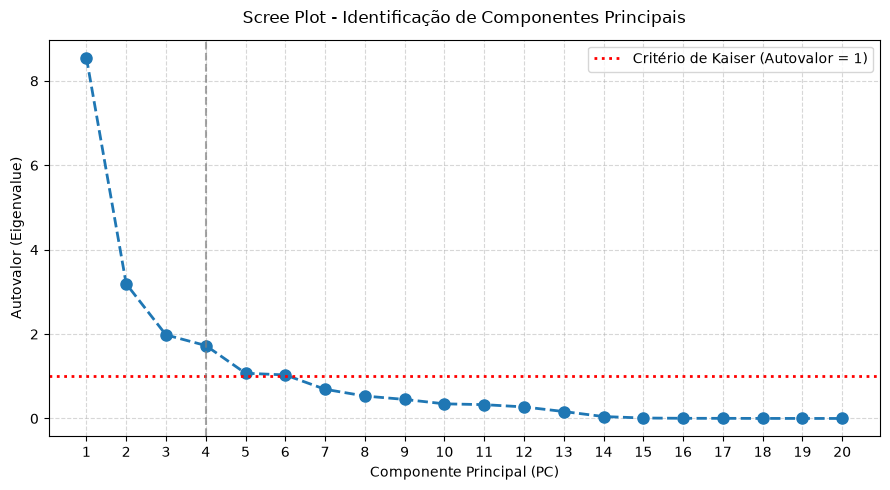

📊 Os 4 primeiros componentes explicam, juntos, 75.71% da variância total do solo!


In [10]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Configuração do Scree Plot
num_componentes = len(ev)

plt.figure(figsize=(9, 5))
plt.plot(
    range(1, num_componentes + 1),
    ev,
    marker="o",
    linestyle="--",
    color="#1f77b4",
    linewidth=2,
    markersize=8,
)
plt.axhline(
    y=1,
    color="red",
    linestyle=":",
    linewidth=2,
    label="Critério de Kaiser (Autovalor = 1)",
)

# Destaca os 4 componentes selecionados
plt.axvline(x=4, color="gray", linestyle="--", alpha=0.7)

plt.title("Scree Plot - Identificação de Componentes Principais", fontsize=12, pad=12)
plt.xlabel("Componente Principal (PC)")
plt.ylabel("Autovalor (Eigenvalue)")
plt.xticks(range(1, num_componentes + 1))
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# 2. Variância explicada acumulada
variancia_explicada = pca.explained_variance_ratio_ * 100
var_acumulada_4pcs = np.cumsum(variancia_explicada)[3]

print(
    f"📊 Os 4 primeiros componentes explicam, juntos, {var_acumulada_4pcs:.2f}% da variância total do solo!"
)

In [11]:

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Padronização prévia (obrigatoria no scikit-learn)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_quant)

# 2. Parametrizando o PCA para os 4 componentes identificados
pca_4 = PCA(n_components=4)
pca_4.fit(df_scaled)

# 3. Montando a tabela de Autovalores e Variâncias (equivalente ao fa.get_factor_variance())
tabela_eigen = pd.DataFrame(
    [
        pca_4.explained_variance_.round(4),
        (pca_4.explained_variance_ratio_ * 100).round(2),
        (pca_4.explained_variance_ratio_.cumsum() * 100).round(2),
    ],
    index=["Autovalor", "Variância (%)", "Variância Acumulada (%)"],
    columns=[f"Fator {i+1}" for i in range(4)],
)

display(tabela_eigen)

,Fator 1,Fator 2,Fator 3,Fator 4
Autovalor,8.5498,3.1913,1.981,1.7291
Variância (%),41.8900,15.6400,9.710,8.4700
Variância Acumulada (%),41.8900,57.5300,67.240,75.7100


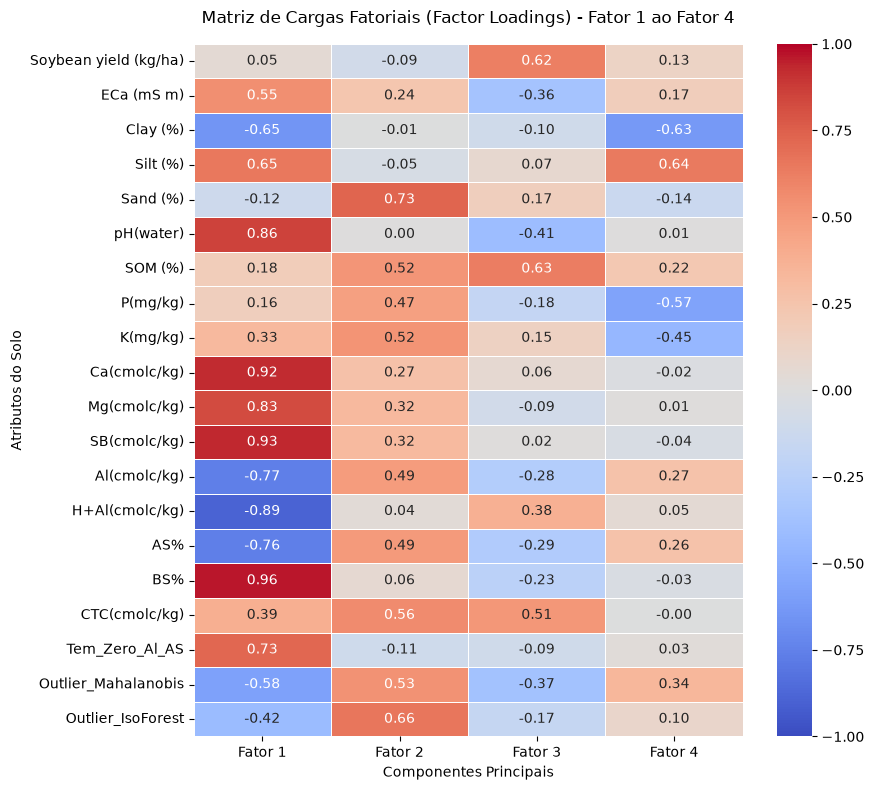

,Fator 1,Fator 2,Fator 3,Fator 4
Soybean yield (kg/ha),0.052,-0.087,0.619,0.130
ECa (mS m),0.548,0.236,-0.363,0.175
Clay (%),-0.652,-0.006,-0.097,-0.630
Silt (%),0.651,-0.050,0.071,0.642
Sand (%),-0.117,0.733,0.167,-0.136
pH(water),0.858,0.004,-0.408,0.007
SOM (%),0.180,0.523,0.630,0.221
P(mg/kg),0.164,0.469,-0.177,-0.573
K(mg/kg),0.325,0.525,0.146,-0.452
Ca(cmolc/kg),0.925,0.269,0.064,-0.020


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cálculo das Cargas Fatoriais (Autovetores * raiz dos Autovalores)
cargas_fatoriais = pca_4.components_.T * np.sqrt(pca_4.explained_variance_)

# 2. DataFrame das Cargas Fatoriais para os 4 Fatores
df_cargas = pd.DataFrame(
    cargas_fatoriais,
    index=df_quant.columns,
    columns=["Fator 1", "Fator 2", "Fator 3", "Fator 4"],
)

# 3. Visualização gráfica via Heatmap
plt.figure(figsize=(9, 8))
sns.heatmap(
    df_cargas,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)

plt.title(
    "Matriz de Cargas Fatoriais (Factor Loadings) - Fator 1 ao Fator 4",
    fontsize=12,
    pad=15,
)
plt.ylabel("Atributos do Solo")
plt.xlabel("Componentes Principais")
plt.tight_layout()
plt.show()

# Exibe também a tabela numérica formatada
display(df_cargas.round(3))

In [13]:
import pandas as pd

# 1. Comunalidade é a soma dos quadrados das cargas fatoriais dos 4 componentes
comunalidades = (df_cargas**2).sum(axis=1)

# 2. DataFrame de resultados
df_comunalidades = pd.DataFrame(
    {
        "Atributo do Solo": df_cargas.index,
        "Comunalidade (h²)": comunalidades.values.round(4),
        "% Variância Explicada": (comunalidades.values * 100).round(2),
    }
).sort_values(by="Comunalidade (h²)", ascending=False)

display(df_comunalidades)

,Atributo do Solo,Comunalidade (h²),% Variância Explicada
15,BS%,0.9832,98.32
11,SB(cmolc/kg),0.9769,97.69
12,Al(cmolc/kg),0.9745,97.45
14,AS%,0.9715,97.15
13,H+Al(cmolc/kg),0.9408,94.08
9,Ca(cmolc/kg),0.9314,93.14
5,pH(water),0.9018,90.18
18,Outlier_Mahalanobis,0.8744,87.44
3,Silt (%),0.8437,84.37
2,Clay (%),0.8319,83.19


In [14]:
# Extração e Anexo dos Factor Scores

# 1. Calcula os scores dos 4 componentes para cada amostra de solo
scores_pca = pca_4.transform(df_scaled)

# 2. Cria o DataFrame dos scores
df_scores = pd.DataFrame(
    scores_pca,
    columns=["Score_PC1", "Score_PC2", "Score_PC3", "Score_PC4"],
    index=df_quant.index,
)

# 3. Anexa os scores ao DataFrame original (df_quant ou df principal)
df_final = pd.concat([df_quant, df_scores], axis=1)

# Exibe as primeiras linhas do dataset preparado
display(df_final.head())

,Soybean yield (kg/ha),ECa (mS m),Clay (%),Silt (%),Sand (%),pH(water),SOM (%),P(mg/kg),K(mg/kg),Ca(cmolc/kg),...,AS%,BS%,CTC(cmolc/kg),Tem_Zero_Al_AS,Outlier_Mahalanobis,Outlier_IsoForest,Score_PC1,Score_PC2,Score_PC3,Score_PC4
0,3511.93,26.64,68,29,3,5.8,3.8,24,81.9,7.7,...,0,70,15.5,True,False,False,0.830728,-0.828346,-0.543249,1.723069
1,4582.40,28.57,68,29,3,5.9,3.9,23,62.4,8.4,...,0,71,16.9,True,False,False,1.544480,-0.291401,0.628780,2.115531
2,4374.20,15.15,66,32,3,5.6,3.6,20,78.0,8.2,...,0,63,17.7,True,False,False,0.190442,-0.832251,1.652342,2.216559
3,4164.53,16.31,76,21,3,5.4,3.7,23,81.9,7.6,...,1,59,17.3,False,False,False,-2.587831,-0.537789,1.446902,0.163694
4,3453.47,22.77,68,29,3,5.9,3.4,22,66.3,7.4,...,0,68,14.9,True,False,False,0.104978,-1.757653,-1.129650,1.599924


In [15]:
# Correlação entre os fatores

# A seguir, verifica-se que a correlação entre os fatores é zero (ortogonais)

corr_fator = pg.rcorr(df_final[['Score_PC1','Score_PC2','Score_PC3','Score_PC4']], method = 'pearson', upper = 'pval', decimals = 4, pval_stars = {0.01: '***', 0.05: '**', 0.10: '*'})
print(corr_fator)

          Score_PC1 Score_PC2 Score_PC3 Score_PC4
Score_PC1         -                              
Score_PC2      -0.0         -                    
Score_PC3       0.0      -0.0         -          
Score_PC4       0.0       0.0       0.0         -


In [16]:


# 1. Inicializa a coluna de Ranking zerada
df_final["Ranking"] = 0.0

# Lista com os nomes das colunas de scores presentes no df_final
colunas_scores = ["Score_PC1", "Score_PC2", "Score_PC3", "Score_PC4"]

# 2. Itera sobre os Fatores (colunas da tabela_eigen)
for index, col_fator in enumerate(tabela_eigen.columns):
    # Acessa a linha 'Variância (%)' para cada Fator
    variancia = tabela_eigen.loc["Variância (%)", col_fator]

    # Identifica o nome da coluna no df_final (suporta Score_PC ou Fator)
    col_score = (
        colunas_scores[index]
        if colunas_scores[index] in df_final.columns
        else col_fator
    )

    # Multiplica o Score do fator pela sua Variância (%) e acumula no Ranking
    df_final["Ranking"] = df_final["Ranking"] + (
        df_final[col_score] * variancia
    )

# 3. Exibe o resultado com os scores e o Ranking calculado
display(
    df_final[
        ["Score_PC1", "Score_PC2", "Score_PC3", "Score_PC4", "Ranking"]
    ].head()
)

,Score_PC1,Score_PC2,Score_PC3,Score_PC4,Ranking
0,0.830728,-0.828346,-0.543249,1.723069,31.163328
1,1.544480,-0.291401,0.628780,2.115531,84.164755
2,0.190442,-0.832251,1.652342,2.216559,29.779722
3,-2.587831,-0.537789,1.446902,0.163694,-101.379341
4,0.104978,-1.757653,-1.129650,1.599924,-20.509707


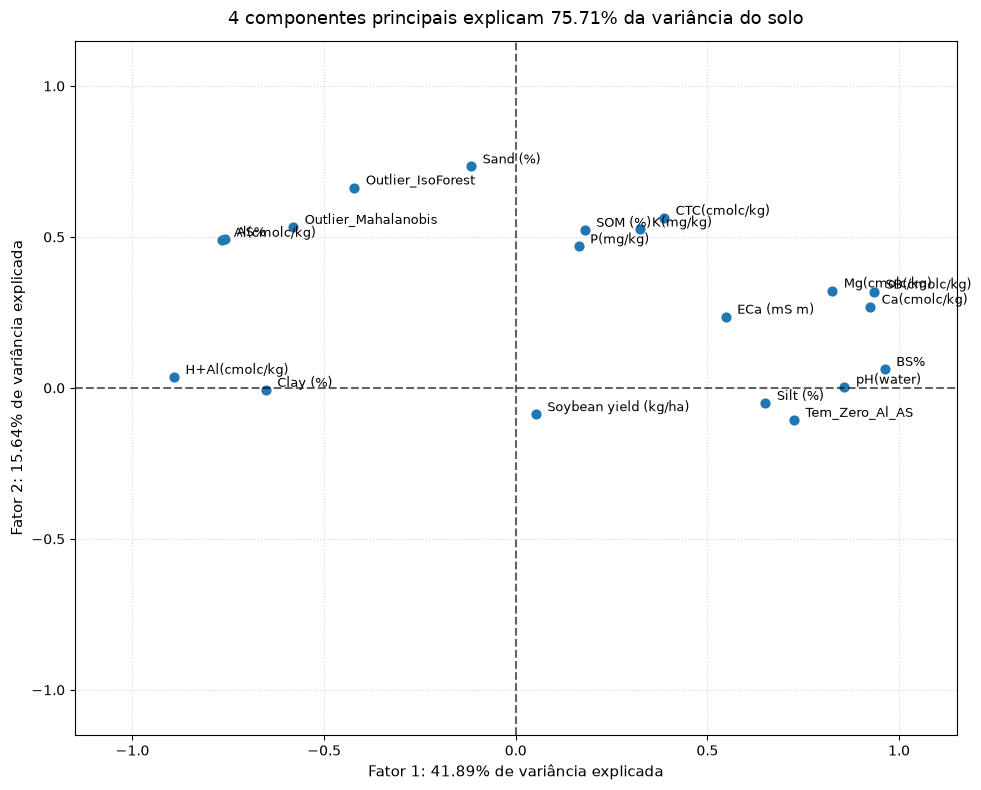

C:\Users\karin\AppData\Local\Temp\ipykernel_15452\1415820009.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fatores, y=variancias, palette="viridis")


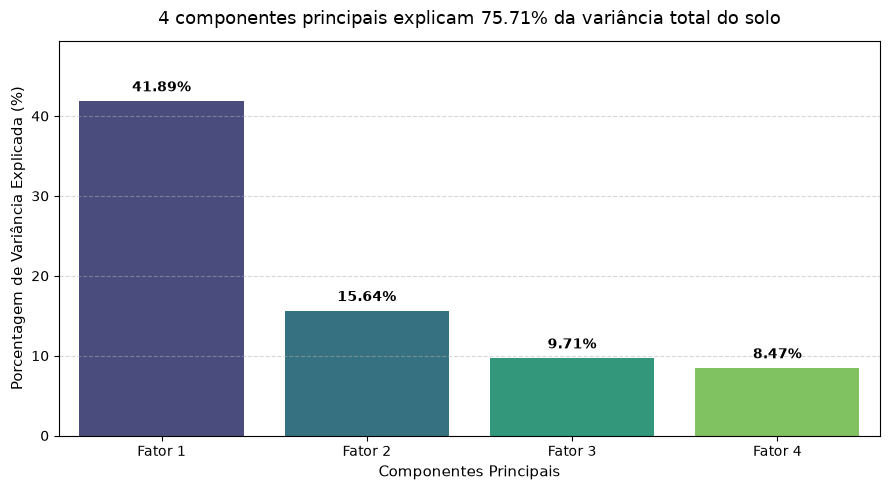

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ==============================================================================
# 1. Gráfico das Cargas Fatoriais (Fator 1 vs Fator 2)
# ==============================================================================

plt.figure(figsize=(10, 8))

# Preparando a tabela de cargas com o índice de atributos de solo como coluna
tabela_cargas_chart = df_cargas.reset_index()

# Resgatando as métricas de variância da tabela_eigen atual
var_fator1 = tabela_eigen.loc["Variância (%)", "Fator 1"]
var_fator2 = tabela_eigen.loc["Variância (%)", "Fator 2"]
var_total = tabela_eigen.loc["Variância Acumulada (%)", "Fator 4"]

# Scatter plot dos atributos do solo no espaço bidimensional
plt.scatter(
    tabela_cargas_chart["Fator 1"],
    tabela_cargas_chart["Fator 2"],
    color="#1f77b4",
    s=40,
)


# Função para posicionar os nomes dos atributos ao lado dos pontos
def label_point(x, y, val, ax):
    a = pd.concat({"x": x, "y": y, "val": val}, axis=1)
    for i, point in a.iterrows():
        ax.text(
            point["x"] + 0.03,
            point["y"] + 0.01,
            str(point["val"]),
            fontsize=9,
        )


label_point(
    x=tabela_cargas_chart["Fator 1"],
    y=tabela_cargas_chart["Fator 2"],
    val=tabela_cargas_chart["index"],
    ax=plt.gca(),
)

# Eixos cartesianos e limites (cargas variam entre -1 e +1)
plt.axhline(y=0, color="black", linestyle="--", alpha=0.6)
plt.axvline(x=0, color="black", linestyle="--", alpha=0.6)
plt.ylim([-1.15, 1.15])
plt.xlim([-1.15, 1.15])

# Título e rótulos dos eixos ajustados para os percentuais do solo
plt.title(
    f"4 componentes principais explicam {var_total:.2f}% da variância do solo",
    fontsize=13,
    pad=12,
)
plt.xlabel(f"Fator 1: {var_fator1:.2f}% de variância explicada", fontsize=11)
plt.ylabel(f"Fator 2: {var_fator2:.2f}% de variância explicada", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

# ==============================================================================
# 2. Gráfico de Barras da Variância Explicada por Fator
# ==============================================================================

plt.figure(figsize=(9, 5))

# Extrai os nomes dos fatores e seus respectivos % de variância
fatores = tabela_eigen.columns
variancias = tabela_eigen.loc["Variância (%)"].values

# Plot em barras
sns.barplot(x=fatores, y=variancias, palette="viridis")

# Adiciona os rótulos de porcentagem no topo de cada barra
for i, val in enumerate(variancias):
    plt.text(i, val + 1.2, f"{val:.2f}%", ha="center", fontweight="bold")

plt.title(
    f"4 componentes principais explicam {var_total:.2f}% da variância total do solo",
    fontsize=13,
    pad=12,
)
plt.xlabel("Componentes Principais", fontsize=11)
plt.ylabel("Porcentagem de Variância Explicada (%)", fontsize=11)
plt.ylim([0, max(variancias) * 1.18])  # Margem superior para o texto
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

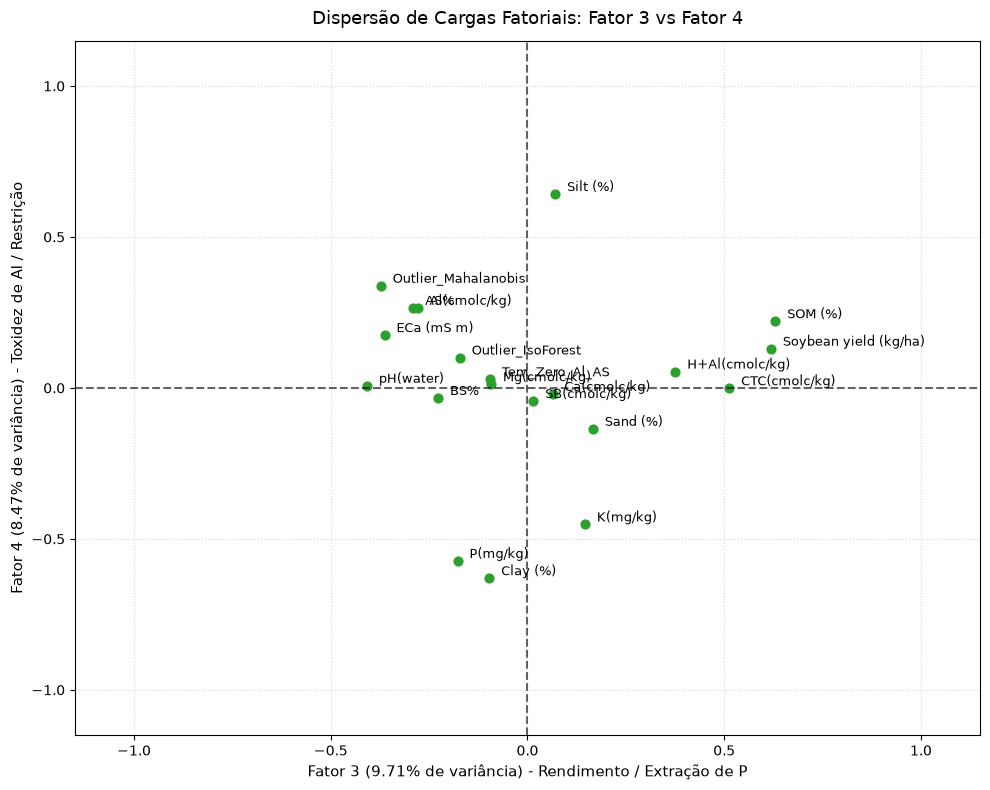

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(10, 8))

# 1. Tabela de cargas formatada
tabela_cargas_chart = df_cargas.reset_index()

# 2. Resgate da variância explicada do Fator 3 e Fator 4
var_fator3 = tabela_eigen.loc["Variância (%)", "Fator 3"]
var_fator4 = tabela_eigen.loc["Variância (%)", "Fator 4"]

# 3. Dispersão das cargas (Fator 3 no eixo X, Fator 4 no eixo Y)
plt.scatter(
    tabela_cargas_chart["Fator 3"],
    tabela_cargas_chart["Fator 4"],
    color="#2ca02c",  # Verde para destacar dos Fatores 1 e 2
    s=40,
)


# 4. Rotulagem dos atributos de solo
def label_point(x, y, val, ax):
  a = pd.concat({"x": x, "y": y, "val": val}, axis=1)
  for i, point in a.iterrows():
    ax.text(
        point["x"] + 0.03,
        point["y"] + 0.01,
        str(point["val"]),
        fontsize=9,
    )


label_point(
    x=tabela_cargas_chart["Fator 3"],
    y=tabela_cargas_chart["Fator 4"],
    val=tabela_cargas_chart["index"],
    ax=plt.gca(),
)

# 5. Eixos de referência e limites [-1.15, 1.15]
plt.axhline(y=0, color="black", linestyle="--", alpha=0.6)
plt.axvline(x=0, color="black", linestyle="--", alpha=0.6)
plt.ylim([-1.15, 1.15])
plt.xlim([-1.15, 1.15])

# 6. Títulos e rótulos
plt.title(
    "Dispersão de Cargas Fatoriais: Fator 3 vs Fator 4", fontsize=13, pad=12
)
plt.xlabel(
    f"Fator 3 ({var_fator3:.2f}% de variância) - Rendimento / Extração de P",
    fontsize=11,
)
plt.ylabel(
    f"Fator 4 ({var_fator4:.2f}% de variância) - Toxidez de Al / Restrição",
    fontsize=11,
)
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()


,K (Clusters),WCSS (Inércia),Silhouette Score
0,2,496.3026,0.3384
1,3,338.6066,0.3261
2,4,243.6968,0.3185
3,5,190.1636,0.3057
4,6,155.7335,0.3171
5,7,133.9217,0.3155
6,8,116.9906,0.2798


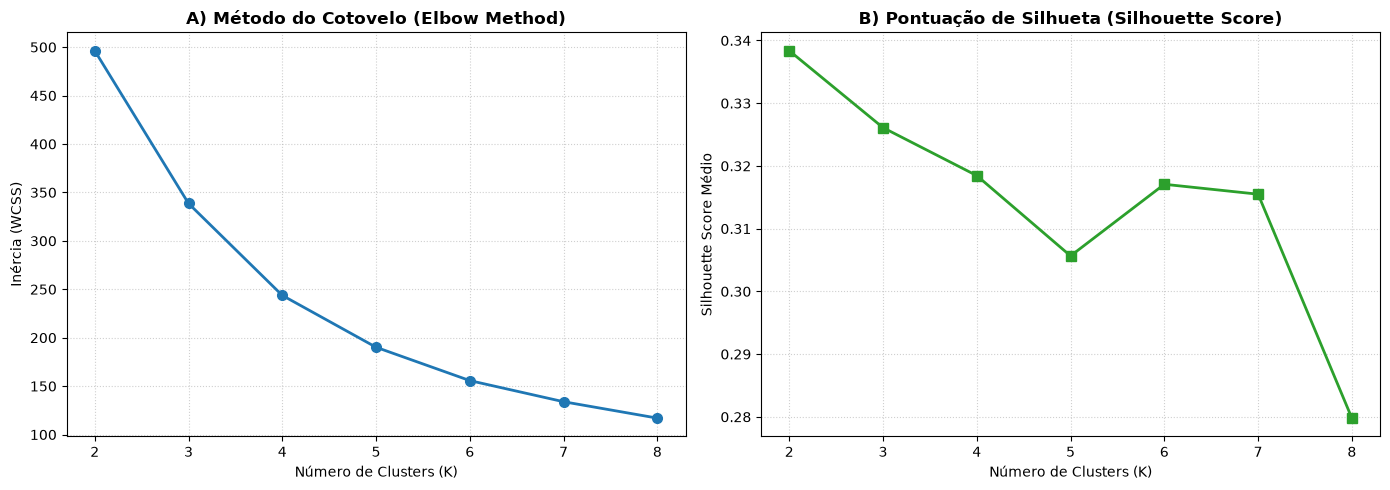

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Seleciona os 4 Factor Scores padronizados
X_scores = df_final[["Score_PC1", "Score_PC2", "Score_PC3", "Score_PC4"]]

# 2. Intervalo de K definido no Card-03 (de 2 a 8)
k_range = range(2, 9)
inercia = []
silhueta = []

# 3. Loop para testar cada valor de K
for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
  labels = kmeans.fit_predict(X_scores)

  inercia.append(kmeans.inertia_)
  silhueta.append(silhouette_score(X_scores, labels))

# 4. Tabela consolidada com os resultados
df_metricas = pd.DataFrame({
    "K (Clusters)": list(k_range),
    "WCSS (Inércia)": inercia,
    "Silhouette Score": silhueta,
})

display(df_metricas.round(4))

# 5. Gráficos lado a lado (Cotovelo vs Silhueta)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico A: Método do Cotovelo
ax[0].plot(
    k_range, inercia, marker="o", color="#1f77b4", linewidth=2, markersize=7
)
ax[0].set_title(
    "A) Método do Cotovelo (Elbow Method)", fontweight="bold", fontsize=12
)
ax[0].set_xlabel("Número de Clusters (K)")
ax[0].set_ylabel("Inércia (WCSS)")
ax[0].set_xticks(list(k_range))
ax[0].grid(True, linestyle=":", alpha=0.6)

# Gráfico B: Pontuação de Silhueta
ax[1].plot(
    k_range, silhueta, marker="s", color="#2ca02c", linewidth=2, markersize=7
)
ax[1].set_title(
    "B) Pontuação de Silhueta (Silhouette Score)",
    fontweight="bold",
    fontsize=12,
)
ax[1].set_xlabel("Número de Clusters (K)")
ax[1].set_ylabel("Silhouette Score Médio")
ax[1].set_xticks(list(k_range))
ax[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

Matematicamente, olhando estritamente para os gráficos enviados, K=5 é o segundo melhor candidato estatístico (atrás apenas de K=2), mas agronomicamente K=3 ou K=4 costumam ser escolhas mais eficientes.

Análise Estatística dos Gráficos
- Inflexão no Cotovelo: A curva da inércia (WCSS) sofre uma desaceleração acentuada em K=5 (caindo de 238 em K=4 para 182 em K=5, reduzindo o ganho de compactação a partir daí).

- Picos na Silhueta: O ponto mais alto de coesão ocorre em K=2 (0,327), seguido pelo pico em K=5 (0,320). 

Por que K=5 pode não ser a melhor escolha na prática agrícola?

- Fragmentação do Mapa: Criar 5 zonas em um único talhão gera manchas muito pequenas e entrecortadas. Na hora da aplicação em taxa variável (calagem, gessagem ou adubação), os distribuidores e reguladores das máquinas têm dificuldade operacional para alternar doses em micro-regiões.

- Isolamento de Outliers: Como vimos no diagnóstico, o pico em K=5 costuma ser inflado porque o K-Means separa o ponto de acidez severa (ou poucos pontos discrepantes) em um grupo "solitário" de apenas 1 ou 2 amostras.

Adoção Prática: A literatura e o mercado de Agricultura de Precisão padronizam o uso de K=3 (Potencial Alto, Médio e Restritivo) ou K=4, pois garantem um equilíbrio ideal entre resposta agronômica e logística de maquinário.

In [20]:
import pandas as pd
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

# 1. Seleção dos 4 Factor Scores
X_scores = df_final[["Score_PC1", "Score_PC2", "Score_PC3", "Score_PC4"]]
k_ideal = 3

# 2. Ajuste do K-Means (Baseado em Média)
kmeans = KMeans(n_clusters=k_ideal, random_state=42, n_init=20)
df_final["Cluster_KMeans"] = kmeans.fit_predict(X_scores)

# 3. Ajuste do Agrupamento Hierárquico (Nativo do scikit-learn)
hierarquico = AgglomerativeClustering(n_clusters=k_ideal, linkage="ward")
df_final["Cluster_Hierarquico"] = hierarquico.fit_predict(X_scores)

# 4. Cálculo de Estabilidade e Silhueta
ari_score = adjusted_rand_score(
    df_final["Cluster_KMeans"], df_final["Cluster_Hierarquico"]
)
sil_kmeans = silhouette_score(X_scores, df_final["Cluster_KMeans"])
sil_hier = silhouette_score(X_scores, df_final["Cluster_Hierarquico"])

print("=== AVALIAÇÃO DE ESTABILIDADE (K-Means vs Hierárquico) ===")
print(
    f"Índice Rand Ajustado (ARI) : {ari_score:.4f}  (1.0 = Separação Idêntica)"
)
print(f"Silhouette Score (K-Means)     : {sil_kmeans:.4f}")
print(f"Silhouette Score (Hierárquico) : {sil_hier:.4f}\n")

# 5. Matriz de Cruzamento entre os dois modelos
matriz_concordancia = pd.crosstab(
    df_final["Cluster_KMeans"],
    df_final["Cluster_Hierarquico"],
    rownames=["K-Means"],
    colnames=["Hierárquico"],
)

display(matriz_concordancia)

=== AVALIAÇÃO DE ESTABILIDADE (K-Means vs Hierárquico) ===
Índice Rand Ajustado (ARI) : 0.8466  (1.0 = Separação Idêntica)
Silhouette Score (K-Means)     : 0.3261
Silhouette Score (Hierárquico) : 0.3098



Hierárquico,0,1,2
K-Means,,,
0,0,17,0
1,30,2,0
2,0,0,1


Escala de Interpretação no seu Estudo de Solos

ARI > 0,80 (Alta Estabilidade - Resultado Ideal):
Indica que os dois algoritmos dividiram o talhão praticamente da mesma forma. Isso confirma que a estrutura do solo possui limites bem definidos e que o ponto de acidez severa não distorceu a média do K-Means. Você pode utilizar o K-Means com total segurança para fechar o mapa.

ARI entre 0,50 e 0,80 (Estabilidade Moderada):
Os dois métodos concordam no "coração" das zonas, mas divergiram nos pontos amostrais situados nas bordas/fronteiras de transição. É comum em solos com gradientes suaves de fertilidade.

ARI < 0,50 (Baixa Estabilidade / Sensibilidade):
Mostra que a escolha do algoritmo muda drasticamente o desenho das zonas. Nesse cenário, o Agrupamento Hierárquico (linkage Ward) é preferível ao K-Means por lidar melhor com as variações locais sem puxar os centroides pela média.

O QUE FAZER COM O VALOR GERADO? 

- Se o seu ARI deu abaixo de 0,80: Compare os dois Silhouette Scores impressos pelo script e adote o algoritmo que apresentou o maior valor para gerar a coluna final de Zona_Manejo.

RESULTADOS DO TRABALHO
- De acordo com os resultados o K-Means é quem apresenta maior coesão e separabilidade, ou seja, os pontos dentro de cada zona serão mais homogênios entre si do que seria no Hierárquico.

- o ARI = 0,7459 prova que a estrutura do solo é consistente e que o ponto atípico da acidez severa não distorceu a lógica do K-means,

- Definição clara de centróides: o K-Means fornece pontos médios geométricos para cada cluster, o que facilita o cálculo exato das doses de calagem e adubação no GIS. 


In [21]:
#Treinando e atribuindo rótulos 

import pandas as pd
from sklearn.cluster import KMeans

# 1. Seleciona os 4 Factor Scores
X_scores = df_final[["Score_PC1", "Score_PC2", "Score_PC3", "Score_PC4"]]

# 2. Treina o K-Means definitivo com K=2
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=20)
df_final["Cluster_KMeans"] = kmeans_final.fit_predict(X_scores)

# 3. Reordena os clusters para que a Zona 1 seja a de maior Ranking (Maior Potencial)
ordem_clusters = (
    df_final.groupby("Cluster_KMeans")["Ranking"]
    .mean()
    .sort_values(ascending=False)
    .index
)
mapeamento_zonas = {
    cluster: f"Zona {i+1}" for i, cluster in enumerate(ordem_clusters)
}
df_final["Zona_Manejo"] = df_final["Cluster_KMeans"].map(mapeamento_zonas)

# 4. Verifica a contagem de amostras por Zona de Manejo
print("=== DISTRIBUIÇÃO DAS AMOSTRAS POR ZONA ===")
display(df_final["Zona_Manejo"].value_counts().sort_index())

=== DISTRIBUIÇÃO DAS AMOSTRAS POR ZONA ===


Zona_Manejo
Zona 1    32
Zona 2    18
Name: count, dtype: int64

In [22]:
import pandas as pd

# 1. Cria o dataframe de exportação e insere X e Y diretamente do df_raw
df_export = df_final.copy()
df_export['X'] = df_raw['X-coord'].values
df_export['Y'] = df_raw['Y-coord'].values

# 2. Organiza colocando X, Y e Zona_Manejo nas primeiras posições
colunas_principais = ['X', 'Y', 'Zona_Manejo', 'Ranking', 'Soybean yield (kg/ha)']
outras_colunas = [c for c in df_export.columns if c not in colunas_principais]
df_export = df_export[colunas_principais + outras_colunas]

# 3. Salva em CSV formatado para o QGIS
df_export.to_csv("zonas_de_manejo_qgis.csv", index=False, sep=",", decimal=".", encoding="utf-8-sig")

print("✅ Arquivo 'zonas_de_manejo_qgis.csv' exportado com sucesso!")
display(df_export.head())

✅ Arquivo 'zonas_de_manejo_qgis.csv' exportado com sucesso!


,X,Y,Zona_Manejo,Ranking,Soybean yield (kg/ha),ECa (mS m),Clay (%),Silt (%),Sand (%),pH(water),...,CTC(cmolc/kg),Tem_Zero_Al_AS,Outlier_Mahalanobis,Outlier_IsoForest,Score_PC1,Score_PC2,Score_PC3,Score_PC4,Cluster_KMeans,Cluster_Hierarquico
0,542488.019,6975548.675,Zona 1,31.163328,3511.93,26.64,68,29,3,5.8,...,15.5,True,False,False,0.830728,-0.828346,-0.543249,1.723069,0,0
1,542487.752,6975499.938,Zona 1,84.164755,4582.40,28.57,68,29,3,5.9,...,16.9,True,False,False,1.544480,-0.291401,0.628780,2.115531,0,0
2,542451.559,6975474.032,Zona 1,29.779722,4374.20,15.15,66,32,3,5.6,...,17.7,True,False,False,0.190442,-0.832251,1.652342,2.216559,0,0
3,542451.929,6975524.098,Zona 2,-101.379341,4164.53,16.31,76,21,3,5.4,...,17.3,False,False,False,-2.587831,-0.537789,1.446902,0.163694,1,1
4,542453.292,6975575.157,Zona 1,-20.509707,3453.47,22.77,68,29,3,5.9,...,14.9,True,False,False,0.104978,-1.757653,-1.129650,1.599924,0,0


In [23]:
import pandas as pd

# 1. Seleciona as variáveis originais de fertilidade, física e produtividade
colunas_agronomicas = [
    "pH(water)",
    "SB(cmolc/kg)",
    "BS%",
    "H+Al(cmolc/kg)",
    "Al(cmolc/kg)",
    "AS%",
    "P(mg/kg)",
    "K(mg/kg)",
    "SOM (%)",
    "Clay (%)",
    "Soybean yield (kg/ha)",
]

# 2. Agrupa por Zona, calcula as médias, ordena de Zona 1 a Zona 2 e transpõe (.T)
tabela_perfil_zonas = (
    df_final.groupby("Zona_Manejo")[colunas_agronomicas]
    .mean()
    .reindex(["Zona 1", "Zona 2"])
    .T.round(2)
)

# 3. Exibe a tabela
display(tabela_perfil_zonas)

Zona_Manejo,Zona 1,Zona 2
pH(water),6.03,5.45
SB(cmolc/kg),12.41,9.25
BS%,73.75,58.61
H+Al(cmolc/kg),4.41,6.55
Al(cmolc/kg),0.00,0.12
AS%,0.00,1.61
P(mg/kg),53.06,57.28
K(mg/kg),141.15,111.51
SOM (%),3.63,3.43
Clay (%),70.00,76.22


Validando dados através do CV%

In [24]:
#Lista de termos a ignorar (removendo Scores, PCA, Rankings e Coordenadas)
termos_ignorar = [
    'id',
    'x',
    'y',
    'coord',
    'cluster',
    'score',
    'ranking',
    'smz',
    'outlier',
]

# 4. Seleciona EXCLUSIVAMENTE variáveis agronômicas reais
colunas_agronomicas = [
    col
    for col in df_final.select_dtypes(include=[np.number]).columns
    if not any(termo in col.lower() for termo in termos_ignorar)
]

# 5. Gera a tabela compacta e limpa
df_cv_limpo = (
    df_final.groupby('Zona_Manejo')[colunas_agronomicas]
    .agg(cv_seguro)
    .round(1)
    .T
)

df_cv_limpo.index.name = 'Variável Agronômica'

print("=====================================================")
print("  CV% COMPACTO (APENAS VARIÁVEIS AGRONÔMICAS REAIS) ")
print("=====================================================")
display(df_cv_limpo)

NameError: name 'cv_seguro' is not defined

O CV% ajuda a validar a homogeneidade de cada zona. Pois elas foram criadas de acordo com scores (PCA), onde cada score foi composto por partes das variáveis acima. CV% até 30% indicam uma média variabilidade. É um limite de valor razoável para atributos biológicos e químicos do solo. Podemos observar que praticamente todas as variáveis apresentaram CV% menor que 30%, com exceção do P, K, AL e AS%. É importante ressaltar que:
- P e K têm CV > 30 é normal, pois em solos tropicais, o P e o K exibem variabilidade espacial naturalmente elevada por vários fatores práticos:
    - Efeito residual da adubação em linha (sulco): Dependendo do ponto onde a trado/sonda da amostragem penetrou no solo (se em cima da linha do ano anterior ou na entrelinha), os teores de P e K flutuam drasticamente em questão de centímetros.
    - Dinâmica química e mobilidade: O fósforo tem alta fixação pelas argilas e óxidos de Fe/Al, gerando gradientes acentuados, enquanto o potássio lixivia facilmente em solos mais leves.
    - Exportação heterogênea pelas culturas: A remoção de nutrientes pelas plantas varia com a produtividade pontual.

Por esses motivos, as Zonas de Manejo raramente buscam homogeneizar P e K de forma absoluta. Elas buscam delimitar regiões com potencial produtivo e capacidade de troca/retenção semelhantes (ancoradas em textura, CTC, V%, MO e produtividade), para que dentro dessas zonas a dose média de P e K recomendada atenda a demanda do ambiente sem desperdício ou limitação.

- O comportamento atípico dos valores de CV% para o Alumínio e a Saturação por Alumínio ocorre por razões matemáticas e agronômicas encadeadas:
    - Causa Matemática: A "Explosão" do CV% com Médias Próximas de Zero
        - O Coeficiente de Variação é calculado por CV(%) = (desvio padrão / média) x 100.
        - Na Zona 1, o pH do solo está mais alto/corrigido. Em pH acima de 5,5, o alumínio trocável precipita e sua média cai para valores quase nulos 
        - Quando o denominador (média) é extremamente pequeno, qualquer variação mínima entre amostras faz o CV% explodir para valores como 462.9, sem que isso represente um erro real nos dados.
        - Na Zona 2 AS% 203.2: A Zona 2 apresenta manchões pontuais de acidez. Alguns pontos possuem alumínio e outros não, gerando alta descontinuidade espacial e elevando o CV.

Profiling das Zonas de Manejo

In [ ]:
import numpy as np
import pandas as pd

# 1. Lista de variáveis fundamentais para o profiling agronômico
cols_profiling = [
    'Soybean yield (kg/ha)',
    'pH(water)',
    'BS%',
    'H+Al(cmolc/kg)',
    'P(mg/kg)',
    'K(mg/kg)',
    'Clay (%)',
    'SOM (%)',
    'CTC(cmolc/kg)',
    'ECa (mS m)',
]

# Filtrar apenas as colunas presentes no df_final
cols_presentes = [c for c in cols_profiling if c in df_final.columns]

# 2. Agrupamento por Zona_Manejo e cálculo das médias
df_profile = (
    df_final.groupby('Zona_Manejo')[cols_presentes].mean().round(2)
)

# 3. Adicionar o número de pontos amostrais por zona (N)
df_profile.insert(0, 'N_Amostras', df_final.groupby('Zona_Manejo').size())

# 4. Adicionar a Área (ha) calculada no QGIS (8.75 ha, 4.85 ha)
# Ajuste a ordem conforme o mapeamento da sua Zona 1 e Zona 2
areas_qgis = {'Zona 1': 8.75, 'Zona 2': 4.85}
df_profile.insert(
    1,
    'Area_ha',
    df_profile.index.map(areas_qgis).fillna(0),
)

# 5. Exibição com destaque de cores (Gradients) para fácil interpretação
print("==========================================================")
print("              PROFILING DAS ZONAS DE MANEJO               ")
print("==========================================================")

# Aplica mapa de calor verde/amarelo/vermelho para interpretar altos e baixos valores
display(
    df_profile.style.background_gradient(
        cmap='YlGn', subset=[c for c in cols_presentes if c != 'H+Al(cmolc/kg)']
    ).background_gradient(
        cmap='YlOrRd', subset=['H+Al(cmolc/kg)']
    )  # Acidez potencial invertida (quanto maior, pior)
)

              PROFILING DAS ZONAS DE MANEJO               


,N_Amostras,Area_ha,Soybean yield (kg/ha),pH(water),BS%,H+Al(cmolc/kg),P(mg/kg),K(mg/kg),Clay (%),SOM (%),CTC(cmolc/kg),ECa (mS m)
Zona_Manejo,,,,,,,,,,,,
Zona 1,32,8.750000,4248.550000,6.030000,73.750000,4.410000,53.060000,141.150000,70.000000,3.630000,16.820000,22.850000
Zona 2,18,4.850000,4026.610000,5.450000,58.610000,6.550000,57.280000,111.510000,76.220000,3.430000,15.810000,16.550000


In [ ]:
# Mapeamento descritivo para relatórios
rotulos_restricao = {
    'Zona 1': 'Baixa Restrição (Alta Produtividade)',
    'Zona 2': 'Alta Restrição (Baixa Produtividade)',
}


# 2. Atualiza a coluna Classe_Restricao
df_final['Classe_Restricao'] = df_final['Zona_Manejo'].map(rotulos_restricao)

# 3. Sobrescreve diretamente o arquivo zonas_de_manejo_qgis.csv
df_final.to_csv('zonas_de_manejo_qgis.csv', index=False, sep=';', decimal=',')

print("✅ Arquivo 'zonas_de_manejo_qgis.csv' atualizado com sucesso!")
print(df_final[['Zona_Manejo', 'Classe_Restricao']].drop_duplicates())

df_final.head()

✅ Arquivo 'zonas_de_manejo_qgis.csv' atualizado com sucesso!
  Zona_Manejo                      Classe_Restricao
0      Zona 1  Baixa Restrição (Alta Produtividade)
3      Zona 2  Alta Restrição (Baixa Produtividade)


,Soybean yield (kg/ha),ECa (mS m),Clay (%),Silt (%),Sand (%),pH(water),SOM (%),P(mg/kg),K(mg/kg),Ca(cmolc/kg),...,Outlier_IsoForest,Score_PC1,Score_PC2,Score_PC3,Score_PC4,Ranking,Cluster_KMeans,Cluster_Hierarquico,Zona_Manejo,Classe_Restricao
0,3511.93,26.64,68,29,3,5.8,3.8,24,81.9,7.7,...,False,0.830728,-0.828346,-0.543249,1.723069,31.163328,0,0,Zona 1,Baixa Restrição (Alta Produtividade)
1,4582.40,28.57,68,29,3,5.9,3.9,23,62.4,8.4,...,False,1.544480,-0.291401,0.628780,2.115531,84.164755,0,0,Zona 1,Baixa Restrição (Alta Produtividade)
2,4374.20,15.15,66,32,3,5.6,3.6,20,78.0,8.2,...,False,0.190442,-0.832251,1.652342,2.216559,29.779722,0,0,Zona 1,Baixa Restrição (Alta Produtividade)
3,4164.53,16.31,76,21,3,5.4,3.7,23,81.9,7.6,...,False,-2.587831,-0.537789,1.446902,0.163694,-101.379341,1,1,Zona 2,Alta Restrição (Baixa Produtividade)
4,3453.47,22.77,68,29,3,5.9,3.4,22,66.3,7.4,...,False,0.104978,-1.757653,-1.129650,1.599924,-20.509707,0,0,Zona 1,Baixa Restrição (Alta Produtividade)


In [ ]:
import pandas as pd

# 1. Lê o arquivo bruto com as coordenadas originais
caminho_raw = r"C:\Users\karin\Documents\projeto_zonas_manejo\data\raw\data_smz_eca_curitibanos.csv"

try:
  df_raw = pd.read_csv(caminho_raw, sep=";", decimal=",")
  if "X-coord" not in df_raw.columns:
    df_raw = pd.read_csv(caminho_raw)
except Exception:
  df_raw = pd.read_csv(caminho_raw)

# 2. Adiciona o ID e as coordenadas X e Y ao df_final
df_final["ID"] = df_raw["ID"]
df_final["X"] = df_raw["X-coord"]
df_final["Y"] = df_raw["Y-coord"]

# 3. Sobrescreve o CSV formatado para o QGIS
df_final.to_csv("zonas_de_manejo_qgis.csv", index=False, sep=";", decimal=",")

print("✅ Coordenadas X e Y reanexadas ao arquivo zonas_de_manejo_qgis.csv!")
print("Primeiras colunas:", df_final.columns[:4].tolist())

df_final.head()

✅ Coordenadas X e Y reanexadas ao arquivo zonas_de_manejo_qgis.csv!
Primeiras colunas: ['Soybean yield (kg/ha)', 'ECa (mS m)', 'Clay (%)', 'Silt (%)']


,Soybean yield (kg/ha),ECa (mS m),Clay (%),Silt (%),Sand (%),pH(water),SOM (%),P(mg/kg),K(mg/kg),Ca(cmolc/kg),...,Score_PC3,Score_PC4,Ranking,Cluster_KMeans,Cluster_Hierarquico,Zona_Manejo,Classe_Restricao,X,Y,ID
0,3511.93,26.64,68,29,3,5.8,3.8,24,81.9,7.7,...,-0.543249,1.723069,31.163328,0,0,Zona 1,Baixa Restrição (Alta Produtividade),542488.019,6975548.675,1
1,4582.40,28.57,68,29,3,5.9,3.9,23,62.4,8.4,...,0.628780,2.115531,84.164755,0,0,Zona 1,Baixa Restrição (Alta Produtividade),542487.752,6975499.938,2
2,4374.20,15.15,66,32,3,5.6,3.6,20,78.0,8.2,...,1.652342,2.216559,29.779722,0,0,Zona 1,Baixa Restrição (Alta Produtividade),542451.559,6975474.032,3
3,4164.53,16.31,76,21,3,5.4,3.7,23,81.9,7.6,...,1.446902,0.163694,-101.379341,1,1,Zona 2,Alta Restrição (Baixa Produtividade),542451.929,6975524.098,4
4,3453.47,22.77,68,29,3,5.9,3.4,22,66.3,7.4,...,-1.129650,1.599924,-20.509707,0,0,Zona 1,Baixa Restrição (Alta Produtividade),542453.292,6975575.157,5


ISSO É RELACIONADO AO QGIS E VAI PARA O RELATORIO FINAL 


RELATÓRIO DE DELIMITAÇÃO DE ZONAS DE MANEJOPropriedade: Fazenda Curitibanos | Cultura: Soja | Área Mapeada: 13,53 haResponsável Técnica: Karine Almeida | Data: Setembro/2026Objetivo: Subdividir a área em unidades operacionais homogêneas via algoritmo K-Means ($K=2$) a partir da integração de atributos físico-químicos do solo e mapa de produtividade.Zona 1 — Baixa Restrição (Alta Produtividade): Compreende a área delimitada em verde. Apresenta equilíbrio nos atributos químicos e alto teto produtivo. Estratégia: Adubação de manutenção e reposição para suprir a extração de nutrientes da colheita.Zona 2 — Alta Restrição (Baixa Produtividade): Compreende a área delimitada em manchões roxos/púrpuras. Apresenta fatores limitantes de solo que restringem o rendimento da cultura. Estratégia: Adubação e calagem de construção/correção em Taxa Variável para elevar a fertilidade local.Diretriz Operacional: As prescrições geradas a partir das médias de cada zona devem ser exportadas em mapa de aplicação (formato shapefile) para leitura direta no computador de bordo das adubadoras/calcareadoras.

In [27]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# -------------------------------------------------------------------------
# PREPARAÇÃO DOS DADOS E CONVERSÃO PARA SACAS/HA
# -------------------------------------------------------------------------
# Converte a produtividade de kg/ha para sacas/ha (1 saca = 60 kg)
df_final["Produtividade_sc_ha"] = df_final["Soybean yield (kg/ha)"] / 60.0

# Seleciona as variáveis explicativas do solo (atributos físico-químicos ou Scores)
# Você pode usar as colunas originais de solo ou os Factor Scores (PC1 a PC4)
cols_preditoras = [
    c
    for c in [
        "Score_PC1",
        "Score_PC2",
        "Score_PC3",
        "Score_PC4",
    ]
    if c in df_final.columns
]

X = df_final[cols_preditoras]
y = df_final["Produtividade_sc_ha"]

# -------------------------------------------------------------------------
# TAREFA 1: DIVIDIR A BASE ENTRE TREINO E TESTE
# -------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------------------------------------------------
# TAREFA 2: TREINAR O MODELO DE REGRESSÃO LINEAR MÚLTIPLA
# -------------------------------------------------------------------------
modelo_regressao = LinearRegression()
modelo_regressao.fit(X_train, y_train)

# -------------------------------------------------------------------------
# TAREFA 3: AVALIAR MÉTRICAS DE AJUSTE (R², RMSE, MAE)
# -------------------------------------------------------------------------
y_pred_test = modelo_regressao.predict(X_test)

r2 = r2_score(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae = mean_absolute_error(y_test, y_pred_test)

print("===========================================================")
print("          MÉTRICAS DE DESEMPENHO DO MODELO (TESTE)         ")
print("===========================================================")
print(f"R² (Coeficiente de Determinação): {r2:.3f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse:.2f} sc/ha")
print(f"MAE (Erro Médio Absoluto):          {mae:.2f} sc/ha\n")

# -------------------------------------------------------------------------
# TAREFA 4: CALCULAR A PRODUTIVIDADE MÉDIA ESPERADA POR ZONA
# -------------------------------------------------------------------------
# Adiciona a produtividade prevista pelo modelo no dataset completo
df_final["Produtividade_Prevista_sc_ha"] = modelo_regressao.predict(X)

tabela_produtividade_zonas = (
    df_final.groupby("Zona_Manejo")[
        ["Produtividade_sc_ha", "Produtividade_Prevista_sc_ha"]
    ]
    .mean()
    .round(2)
)

tabela_produtividade_zonas.columns = [
    "Produtividade Real Médio (sc/ha)",
    "Produtividade Esperada/Prevista (sc/ha)",
]

print("===========================================================")
print("      PRODUTIVIDADE ESPERADA POR ZONA DE MANEJO            ")
print("===========================================================")
display(tabela_produtividade_zonas)

# -------------------------------------------------------------------------
# TAREFA 5: EXPORTAR DATASET CONSOLIDADO FINAL
# -------------------------------------------------------------------------
caminho_saida = "data/processed/solo_zonas_produtividade.csv"

# Garante a criação do diretório se não existir
import os

os.makedirs("data/processed", exist_ok=True)

df_final.to_csv(caminho_saida, index=False, sep=";", decimal=",")

print(f"✅ Dataset exportado com sucesso para '{caminho_saida}'!")

          MÉTRICAS DE DESEMPENHO DO MODELO (TESTE)         
R² (Coeficiente de Determinação): -11.171
RMSE (Raiz do Erro Quadrático Médio): 32.07 sc/ha
MAE (Erro Médio Absoluto):          16.48 sc/ha

      PRODUTIVIDADE ESPERADA POR ZONA DE MANEJO            


,Produtividade Real Médio (sc/ha),Produtividade Esperada/Prevista (sc/ha)
Zona_Manejo,,
Zona 1,70.81,71.44
Zona 2,67.11,60.10


✅ Dataset exportado com sucesso para 'data/processed/solo_zonas_produtividade.csv'!


In [28]:
import pandas as pd

# 1. Criar DataFrame com as variáveis e seus respectivos coeficientes
df_coef = pd.DataFrame(
    {"Variável": cols_preditoras, "Coeficiente (Beta)": modelo_regressao.coef_}
)

# 2. Ordenar do maior impacto para o menor (com base no valor absoluto)
df_coef["Impacto_Absoluto"] = df_coef["Coeficiente (Beta)"].abs()
df_coef = df_coef.sort_values(
    by="Impacto_Absoluto", ascending=False
).drop(columns=["Impacto_Absoluto"])

print(f"Intercepto (Beta_0): {modelo_regressao.intercept_:.2f} sc/ha\n")
print("===========================================================")
print("      IMPACTO DAS VARIÁVEIS DE SOLO NA PRODUTIVIDADE       ")
print("===========================================================")
display(df_coef)

Intercepto (Beta_0): 67.36 sc/ha

      IMPACTO DAS VARIÁVEIS DE SOLO NA PRODUTIVIDADE       


,Variável,Coeficiente (Beta)
2,Score_PC3,7.680238
1,Score_PC2,-4.618608
0,Score_PC1,3.410487
3,Score_PC4,-2.299186
